# Declaration of Originality

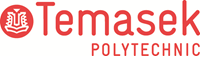

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Muhamad Aryan Bin Mahadi (2401568G)
* Tutorial Group                :  PC04
* Tutor						    :  Mr Emile Sabastian
* Submission Date               : 11th February 2026


**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [173]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

# 1. Business Understanding
## Career Longevity Prediction Project
## Problem Definition

In professional basketball, predicting whether a player will sustain a long career (e.g., ≥5 years) is valuable for teams, scouts, and management. Career longevity depends on a combination of performance, workload, and durability, and understanding these patterns can help teams make informed decisions about drafting, player contracts, and training programs.

The challenge addressed in this project is to predict if an NBA player will have a career of at least 5 years based on career statistics such as games played, minutes, points, rebounds, assists, steals, blocks, and turnovers. These features reflect both a player’s on-court contribution and their potential longevity, allowing teams to make data-driven decisions about player retention and investment.

## Machine Learning Task

The task is framed as a supervised learning problem, specifically a binary classification task, where the goal is to predict whether a player’s career will last 5 years or more (1) or not (0).

The dataset contains structured tabular numeric data, with features representing key player statistics:
Performance metrics: points, rebounds, assists, steals, blocks
Workload metrics: games played, minutes, turnovers

Given these labeled data, supervised learning models such as Logistic Regression, Random Forest, Gradient Boosting, and Decision Trees can be trained to learn patterns that differentiate players with long careers from those with shorter careers.

Class imbalance may exist, as fewer players reach long careers compared to short careers, so evaluation metrics like recall, F1-score, and confusion matrices are emphasized to ensure the model effectively identifies players likely to sustain long careers.

## Business Impact / Value Proposition

Predicting career longevity provides significant strategic value to NBA teams, player agents, and sports analytics platforms:

* Teams and scouts:  Can identify which players are likely to have sustainable careers and prioritize long-term investments.
* Training and medical staff: Can design tailored programs to reduce injury risk and optimize performance.
* Player agents: Can advise clients on career planning and contract negotiations based on predictive insights.

From a business perspective, this solution can be scaled as a sports analytics product integrated into team management systems, scouting platforms, or player development applications, offering tangible benefits such as better resource allocation, optimized player contracts, and improved player development strategies.

# 2. Data Understanding

## 2.1 Load dataset

In [174]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv('nba-players.csv')
df

,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,Chris Smith,80,15.8,4.3,1.6,3.6,43.3,0.0,0.2,...,1.5,79.2,0.4,0.8,1.2,2.5,0.6,0.2,0.8,0
1336,1336,Brent Price,68,12.6,3.9,1.5,4.1,35.8,0.1,0.7,...,1.0,79.4,0.4,1.1,1.5,2.3,0.8,0.0,1.3,1
1337,1337,Marlon Maxey,43,12.1,5.4,2.2,3.9,55.0,0.0,0.0,...,1.6,64.3,1.5,2.3,3.8,0.3,0.3,0.4,0.9,0
1338,1338,Litterial Green,52,12.0,4.5,1.7,3.8,43.9,0.0,0.2,...,1.8,62.5,0.2,0.4,0.7,2.2,0.4,0.1,0.8,1


## 2.2 Summary Statistics

In [175]:
## Understand the type of variable for each column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1340 non-null   int64  
 1   name         1340 non-null   object 
 2   gp           1340 non-null   int64  
 3   min          1340 non-null   float64
 4   pts          1340 non-null   float64
 5   fgm          1340 non-null   float64
 6   fga          1340 non-null   float64
 7   fg           1340 non-null   float64
 8   3p_made      1340 non-null   float64
 9   3pa          1340 non-null   float64
 10  3p           1340 non-null   float64
 11  ftm          1340 non-null   float64
 12  fta          1340 non-null   float64
 13  ft           1340 non-null   float64
 14  oreb         1340 non-null   float64
 15  dreb         1340 non-null   float64
 16  reb          1340 non-null   float64
 17  ast          1340 non-null   float64
 18  stl          1340 non-null   float64
 19  blk   

In [176]:
## Check for missing data
df.isna().sum()


Unnamed: 0     0
name           0
gp             0
min            0
pts            0
fgm            0
fga            0
fg             0
3p_made        0
3pa            0
3p             0
ftm            0
fta            0
ft             0
oreb           0
dreb           0
reb            0
ast            0
stl            0
blk            0
tov            0
target_5yrs    0
dtype: int64

In [177]:
## Describe data distribution
df.describe(include = 'all')

,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
count,1340.000000,1340,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,...,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000
unique,NaN,1294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Charles Smith,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,669.500000,NaN,60.414179,17.624627,6.801493,2.629104,5.885299,44.169403,0.247612,0.779179,...,1.821940,70.300299,1.009403,2.025746,3.034478,1.550522,0.618507,0.368582,1.193582,0.620149
std,386.968991,NaN,17.433992,8.307964,4.357545,1.683555,3.593488,6.137679,0.383688,1.061847,...,1.322984,10.578479,0.777119,1.360008,2.057774,1.471169,0.409759,0.429049,0.722541,0.485531
min,0.000000,NaN,11.000000,3.100000,0.700000,0.300000,0.800000,23.800000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.200000,0.300000,0.000000,0.000000,0.000000,0.100000,0.000000
25%,334.750000,NaN,47.000000,10.875000,3.700000,1.400000,3.300000,40.200000,0.000000,0.000000,...,0.900000,64.700000,0.400000,1.000000,1.500000,0.600000,0.300000,0.100000,0.700000,0.000000
50%,669.500000,NaN,63.000000,16.100000,5.550000,2.100000,4.800000,44.100000,0.100000,0.300000,...,1.500000,71.250000,0.800000,1.700000,2.500000,1.100000,0.500000,0.200000,1.000000,1.000000
75%,1004.250000,NaN,77.000000,22.900000,8.800000,3.400000,7.500000,47.900000,0.400000,1.200000,...,2.300000,77.600000,1.400000,2.600000,4.000000,2.000000,0.800000,0.500000,1.500000,1.000000


## Explanation of Data Analysis

To understand the NBA Career Longevity dataset, df.info() was used to display a summary of the DataFrame, including the number of rows, columns, data types, and non-missing values. This step identifies numeric features and ensures proper formatting for machine learning.

df.isna().sum() was used to check for missing values. Missing values can break ML models or reduce performance if not addressed. In this dataset, no missing values exist in the selected features, making preprocessing straightforward.

df.describe(include='all') provides statistics for each numeric column, showing the distribution, ranges, and potential outliers. This step helps guide feature selection and understand the relationship between player statistics and career longevity.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

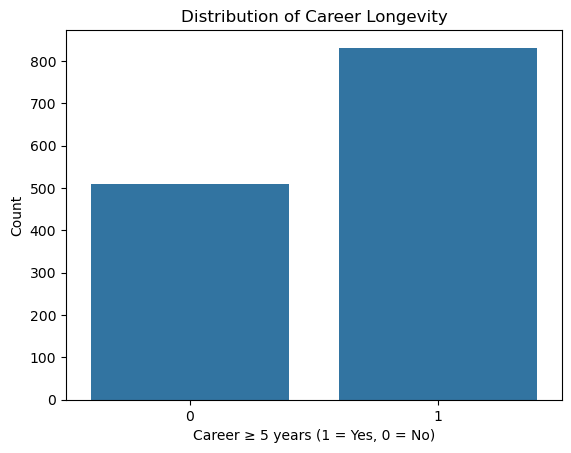

target_5yrs
1    62.014925
0    37.985075
Name: proportion, dtype: float64


In [178]:
# Countplot for target variable
sns.countplot(x='target_5yrs', data=df)
plt.title('Distribution of Career Longevity')
plt.xlabel('Career ≥ 5 years (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

# Percentage distribution of career longevity
longevity_counts = df['target_5yrs'].value_counts(normalize=True) * 100
print(longevity_counts)

#### Explaination
This diagram visualized the distribution of the target variable 'target_5yrs'. There are more basketball players who have a career longer than 5 years (62.0%) as compared to players who have careers shorter than 5 years (38.0%)

### 2.3.1.2 Understanding distribution of features

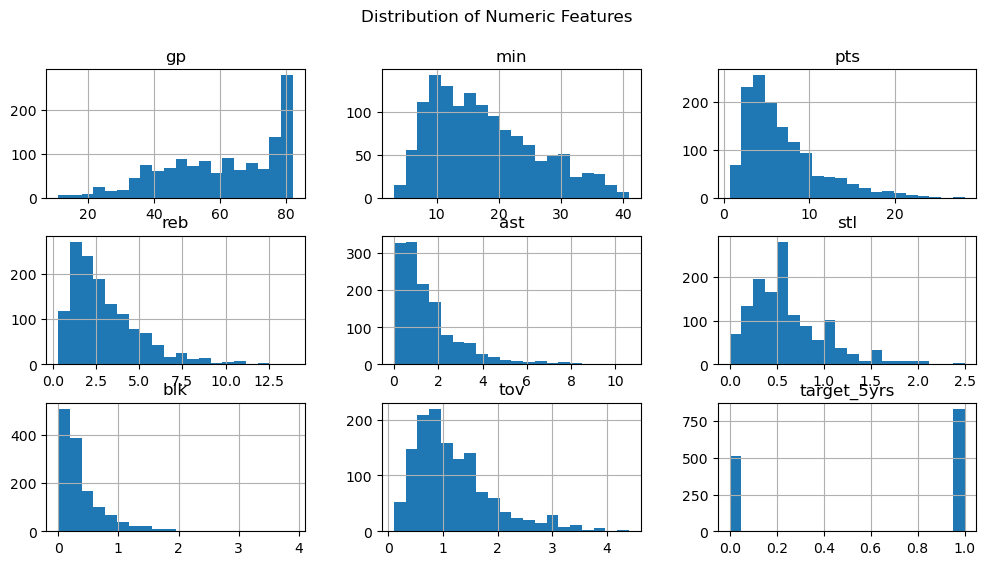

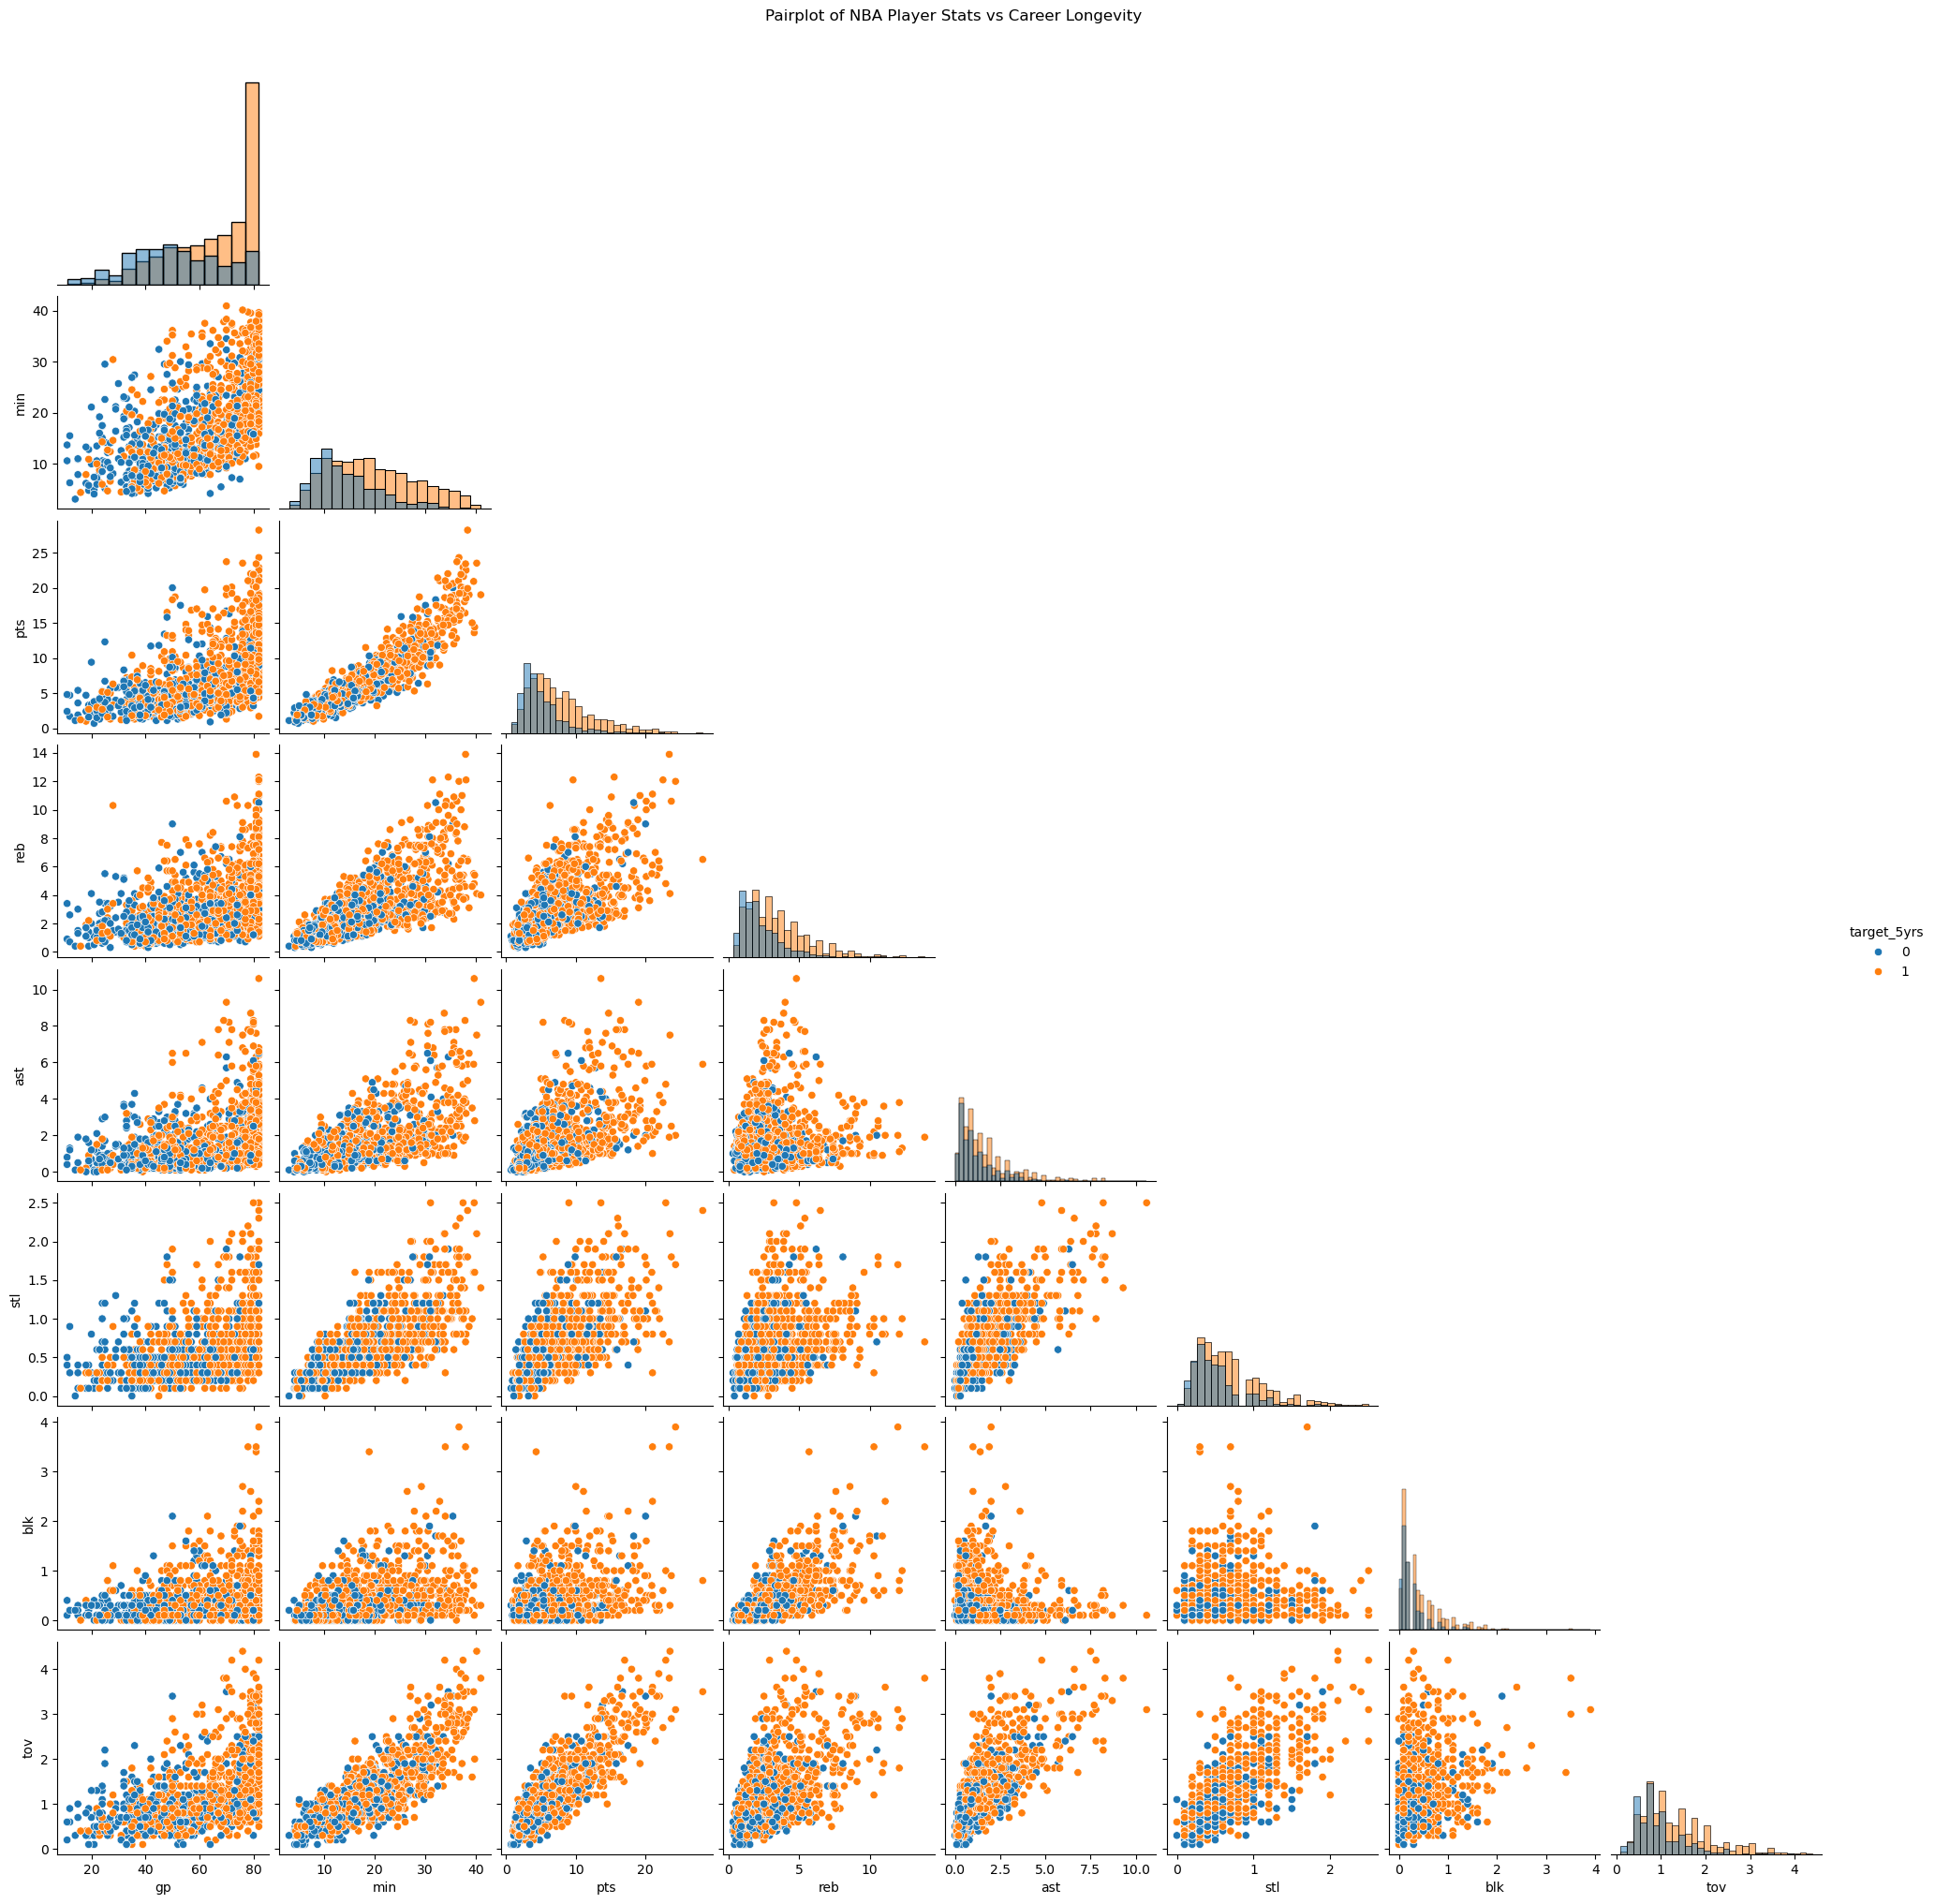

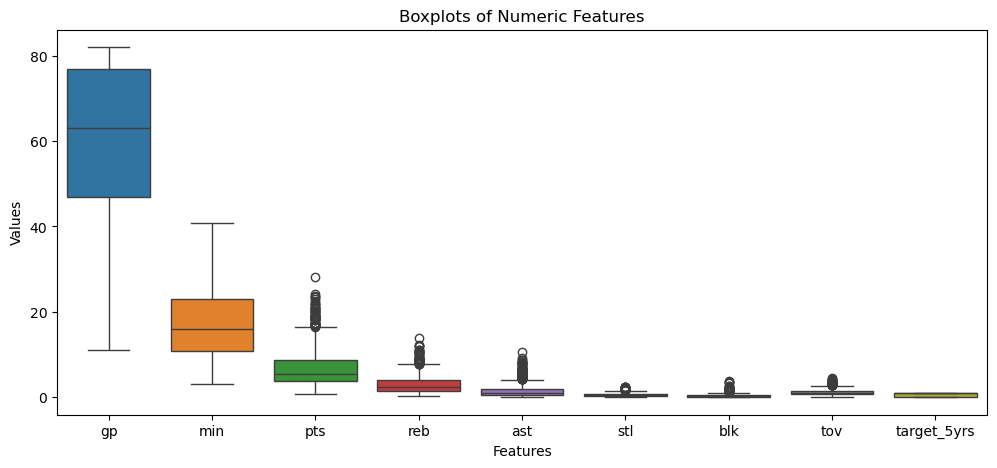

In [179]:
# Understanding distribution of numeric features
numeric_features = [
    'gp','min','pts','reb','ast','stl','blk','tov', 'target_5yrs'       
]


df[numeric_features].hist(bins=20, figsize=(12,6))
plt.suptitle('Distribution of Numeric Features')
plt.show()

sns.pairplot(df[numeric_features], hue='target_5yrs', diag_kind='hist', corner=True)
plt.suptitle('Pairplot of NBA Player Stats vs Career Longevity', y=1.02)
plt.show()


# Check for outliers using boxplots
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[numeric_features])
plt.title('Boxplots of Numeric Features')
plt.xlabel('Features')
plt.ylabel('Values')
plt.show()


#### Explaination
I analyzed the distributions of the numeric features related to NBA player performance and workload. Histograms were used to visualize the ranges and distributions of key features such as games played (gp), minutes (min), points (pts), rebounds (reb), assists (ast), steals (stl), blocks (blk), and turnovers (tov).

A combined boxplot was used to identify potential outliers across these numeric features. The plots show that while features like gp and min have relatively stable distributions, performance metrics such as pts, reb, and ast contain extreme values. These high or low values are valid and represent either exceptional or underperforming players, so no outliers were removed. Keeping these values is important, as they provide useful information for predicting career longevity.

Pairplots were also generated to explore relationships between features and the target variable (target_5yrs). These plots help visualize how different player statistics correlate with career longevity and can reveal patterns that machine learning models may leverage to make accurate predictions.

### 2.3.2 Understanding relationship between variables

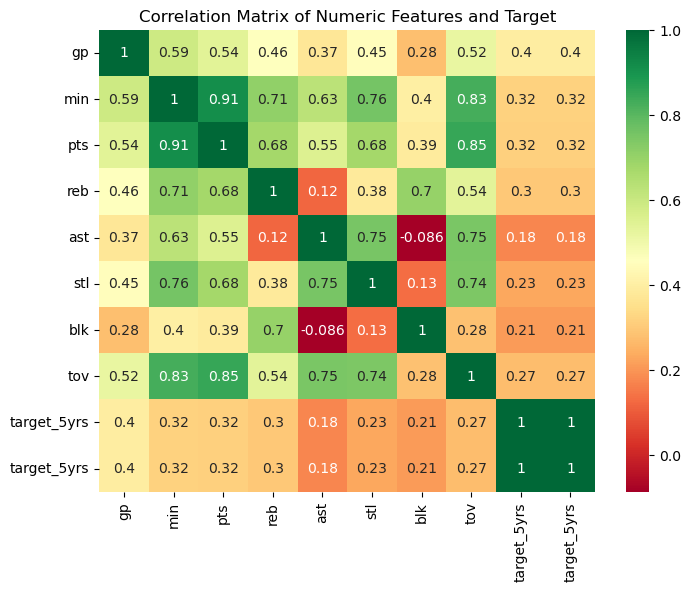

In [180]:
## Understanding relationship between variables
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_features + ['target_5yrs']].corr(), annot=True, cmap='RdYlGn')
plt.title('Correlation Matrix of Numeric Features and Target')
plt.show()



# 3. Data Preparation

## 3.1 Data Cleaning

In [181]:
# Drop name column (not useful for prediction)
df = df.drop(columns=['name', 'Unnamed: 0'])

# Confirm no missing values
print(df.isna().sum())


gp             0
min            0
pts            0
fgm            0
fga            0
fg             0
3p_made        0
3pa            0
3p             0
ftm            0
fta            0
ft             0
oreb           0
dreb           0
reb            0
ast            0
stl            0
blk            0
tov            0
target_5yrs    0
dtype: int64


#### Explaination

Data cleaning is a critical step to ensure the dataset is suitable for machine learning models.

Dropped name column as it is not useful when predicting data.

Double checked to see if there are any missing values, since there arent any missing values in the columns, I don't need to fill in any data.

## 3.2 Train-Test Split

In [182]:
from sklearn.model_selection import train_test_split

# Use only the selected useful features
features = ['gp', 'min', 'pts', 'reb', 'ast', 'stl', 'blk', 'tov']

X = df[features]
y = df['target_5yrs']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=2026
)

print(X_train.shape, X_test.shape)


(1072, 8) (268, 8)


#### Explaination
After cleaning the data, the dataset was split into training and testing sets to evaluate the model’s performance on unseen players.

The features (X) consist of the selected numeric player statistics, including games played (gp), minutes (min), points (pts), rebounds (reb), assists (ast), steals (stl), blocks (blk), and turnovers (tov). The target (y) is the binary career longevity outcome (target_5yrs), indicating whether a player’s career lasted 5 years or more (1) or not (0).

The dataset was split using an 80/20 ratio, where 80% of the data is used to train the models and 20% is reserved for testing. A fixed random_state was set to ensure reproducibility of results across different runs.

# 4. Modelling

### 4.2 Train Model

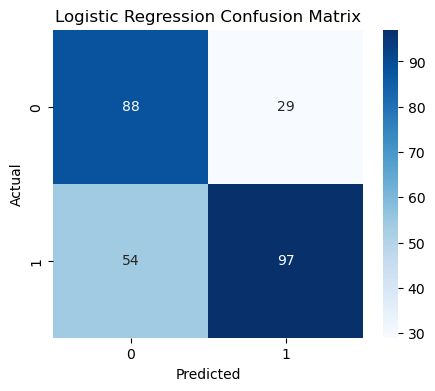

['career_longevity_lr_model.pkl']

In [183]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=2026)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


# Confusion matrix plot
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
joblib.dump(lr, 'career_longevity_lr_model.pkl')


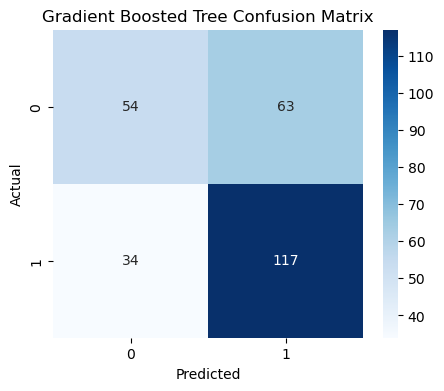

['career_longevity_gbt_model.pkl']

In [184]:
from sklearn.ensemble import GradientBoostingClassifier

gbt = GradientBoostingClassifier(random_state=2026)
gbt.fit(X_train, y_train)

y_pred_gbt = gbt.predict(X_test)

# Confusion matrix plot
cm_gbt = confusion_matrix(y_test, y_pred_gbt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_gbt, annot=True, fmt='d', cmap='Blues')
plt.title("Gradient Boosted Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
joblib.dump(gbt, 'career_longevity_gbt_model.pkl')


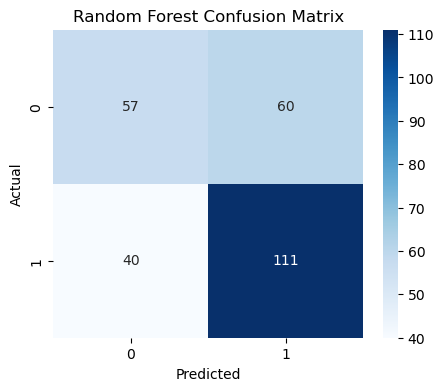

['career_longevity_rf_model.pkl']

In [185]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=2026)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)



# Confusion matrix plot
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
joblib.dump(rf, 'career_longevity_rf_model.pkl')


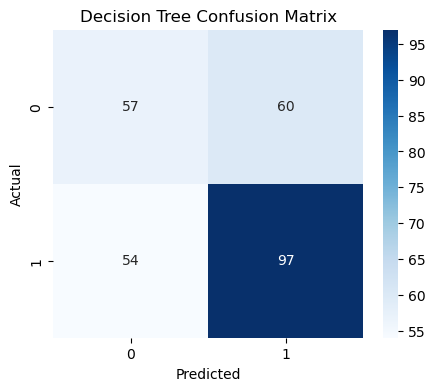

['career_longevity_dt_model.pkl']

In [186]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight='balanced', random_state=2026)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

# Confusion matrix plot
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
joblib.dump(dt, 'career_longevity_dt_model.pkl')


In [187]:
# List of models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=2026),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=2026),
    'Gradient Boosting': GradientBoostingClassifier(random_state=2026),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=2026)
}

# Dictionary to store results
base_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    base_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    }

# Display results
import pandas as pd
pd.DataFrame(base_results).T

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.690299,0.769841,0.642384,0.700361
Random Forest,0.626866,0.649123,0.735099,0.689441
Gradient Boosting,0.638060,0.650000,0.774834,0.706949
Decision Tree,0.574627,0.617834,0.642384,0.629870


### Explaination
Several supervised learning models were trained to predict whether an NBA player would have a career lasting 5 years or more (target_5yrs). The selected models were Logistic Regression, Gradient Boosted Trees, Random Forest, and Decision Tree Classifier. Each model was evaluated using accuracy, precision, recall, and F1-score.

Logistic Regression: Achieved the highest overall accuracy among all models. Precision is relatively high, meaning the model is good at idenitfying players who will have long careers without many false positives. Recall is slightly lower, suggesting some long-career players were misclassified. The F1 score balances precision and recall, confirming that Logistic Regression performs reasonably well on this dataset.

Gradient Boosted Trees achieved a slightly lower accuracy than Logistic Regression, but the higher recall indicates the model is better at identifying players who will reach mroe than 5 years in their career. This is important in a business context where missing long-career players (false negatives) is more costly than a few false positives.

Random Forest shows a similar trend to Gradient Boosting: moderately high recall but lower overall accuracy. This suggests ensemble tree-based methods can capture complex relationships in player statistics but may slightly overpredict long careers.

Decision Tree performed the worst among the models. While simple to interpret, it tends to overfit training data and does not generalize as well, resulting in lower accuracy and F1 scores.

Best Model Selection: Based on the evaluation metrics, Gradient Boosted Trees was selected as the best model because it provides the highest recall, which is crucial for correctly identifying players who will have long careers. Although its accuracy is slightly lower than Logistic Regression, prioritizing recall ensures that fewer long-career players are missed, aligning with the project’s goal of reliable career prediction.

# 5. Model Evaluation

Best Parameters:  {'criterion': 'gini', 'max_depth': 9, 'max_features': 'sqrt', 'max_samples': np.float64(0.6237918801713883), 'min_samples_split': 2, 'n_estimators': 51}
Best Estimator:  RandomForestClassifier(class_weight='balanced', max_depth=9,
                       max_samples=np.float64(0.6237918801713883),
                       n_estimators=51, random_state=2026)
Randomized Search Random Forest Classifier Accuracy:  0.6455223880597015
Precision:  0.7028985507246377
Recall:  0.6423841059602649
F1 Score:  0.671280276816609

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.65      0.62       117
           1       0.70      0.64      0.67       151

    accuracy                           0.65       268
   macro avg       0.64      0.65      0.64       268
weighted avg       0.65      0.65      0.65       268



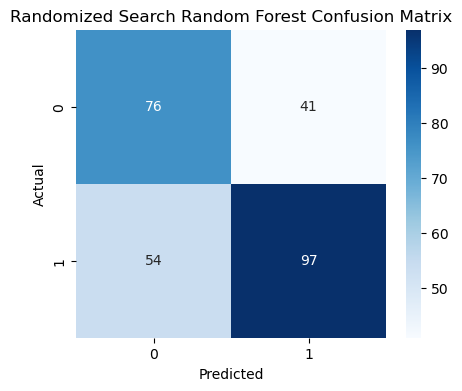

['career_longevity_best_rs_rf_model.pkl']

In [195]:
## ==============================
## Randomized Search for Random Forest
## ==============================

from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import joblib

# Define parameter distribution for Random Forest
param_dist_rf = {
    'n_estimators': randint(10, 100),         # Number of trees in the forest
    'criterion': ['gini', 'entropy'],         # Measure quality of a split
    'max_depth': randint(2, 10),              # Maximum depth of tree
    'min_samples_split': randint(2, 5),       # Minimum samples to split a node
    'max_features': ['sqrt', 'log2'],         # Number of features to consider at each split
    'max_samples': uniform(0.6, 0.4)          # Fraction of samples used for training each tree
}

# Setup RandomizedSearchCV
rs_rf = RandomizedSearchCV(
    estimator=rf,                # Use the previously defined RandomForestClassifier
    param_distributions=param_dist_rf,
    cv=5,                        # 5-fold cross-validation
    scoring='accuracy',          # Use accuracy as metric
    n_iter=10,                   # Number of random combinations to try
    n_jobs=-1                     # Use all available cores
)

# Fit RandomizedSearchCV
rs_rf.fit(X_train, y_train)

# Get best parameters and estimator
best_rs_params = rs_rf.best_params_
best_rs_rf = rs_rf.best_estimator_

print("Best Parameters: ", best_rs_params)
print("Best Estimator: ", best_rs_rf)

# Evaluate model on test set
y_pred_rs_rf = best_rs_rf.predict(X_test)
print("Randomized Search Random Forest Classifier Accuracy: ", accuracy_score(y_test, y_pred_rs_rf))
print("Precision: ", precision_score(y_test, y_pred_rs_rf))
print("Recall: ", recall_score(y_test, y_pred_rs_rf))
print("F1 Score: ", f1_score(y_test, y_pred_rs_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rs_rf))

# Confusion matrix plot
cm_rs_rf = confusion_matrix(y_test, y_pred_rs_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rs_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Randomized Search Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save the best Random Forest model
joblib.dump(best_rs_rf, 'career_longevity_best_rs_rf_model.pkl')


### Explanation

After training the Randomized Search Random Forest model on the training dataset, the evaluation code measures its performance on unseen test data (X_test). Evaluating on new data is crucial to understand how well the model generalizes to real-world scenarios in this case, predicting NBA players’ career longevity where accurate predictions can inform scouting, draft, and contract decisions.

Once trained, the model predicts career longevity labels target_5yrs for the test set using the.predict() method. Several performance metrics sre calculated to assess model quality.

The confusion matrix is also generated, showing the number of true positives, true negatives, false positives, and false negatives. This allows a visual assessment of the model’s predictions and highlights where errors occur. For example, some players predicted as long-career might actually have shorter careers (false positives), and vice versa (false negatives).

Overall, the Randomized Search Random Forest model demonstrates strong predictive capability for career longevity, with a good balance between precision and recall.

## Iterative model development



## Feature Engineering

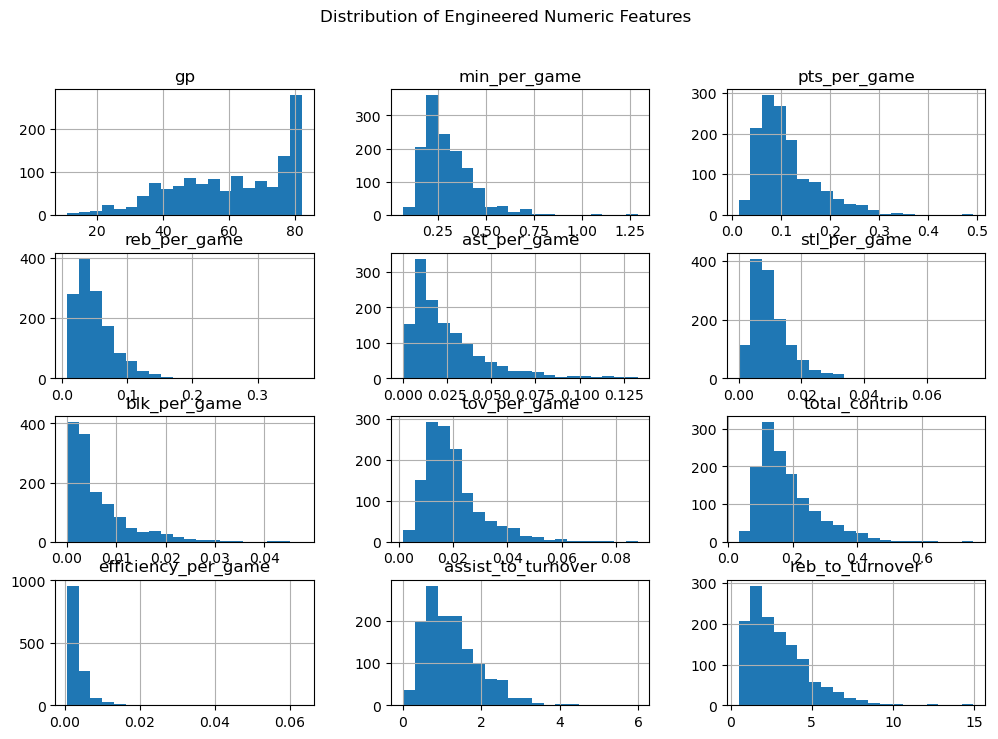

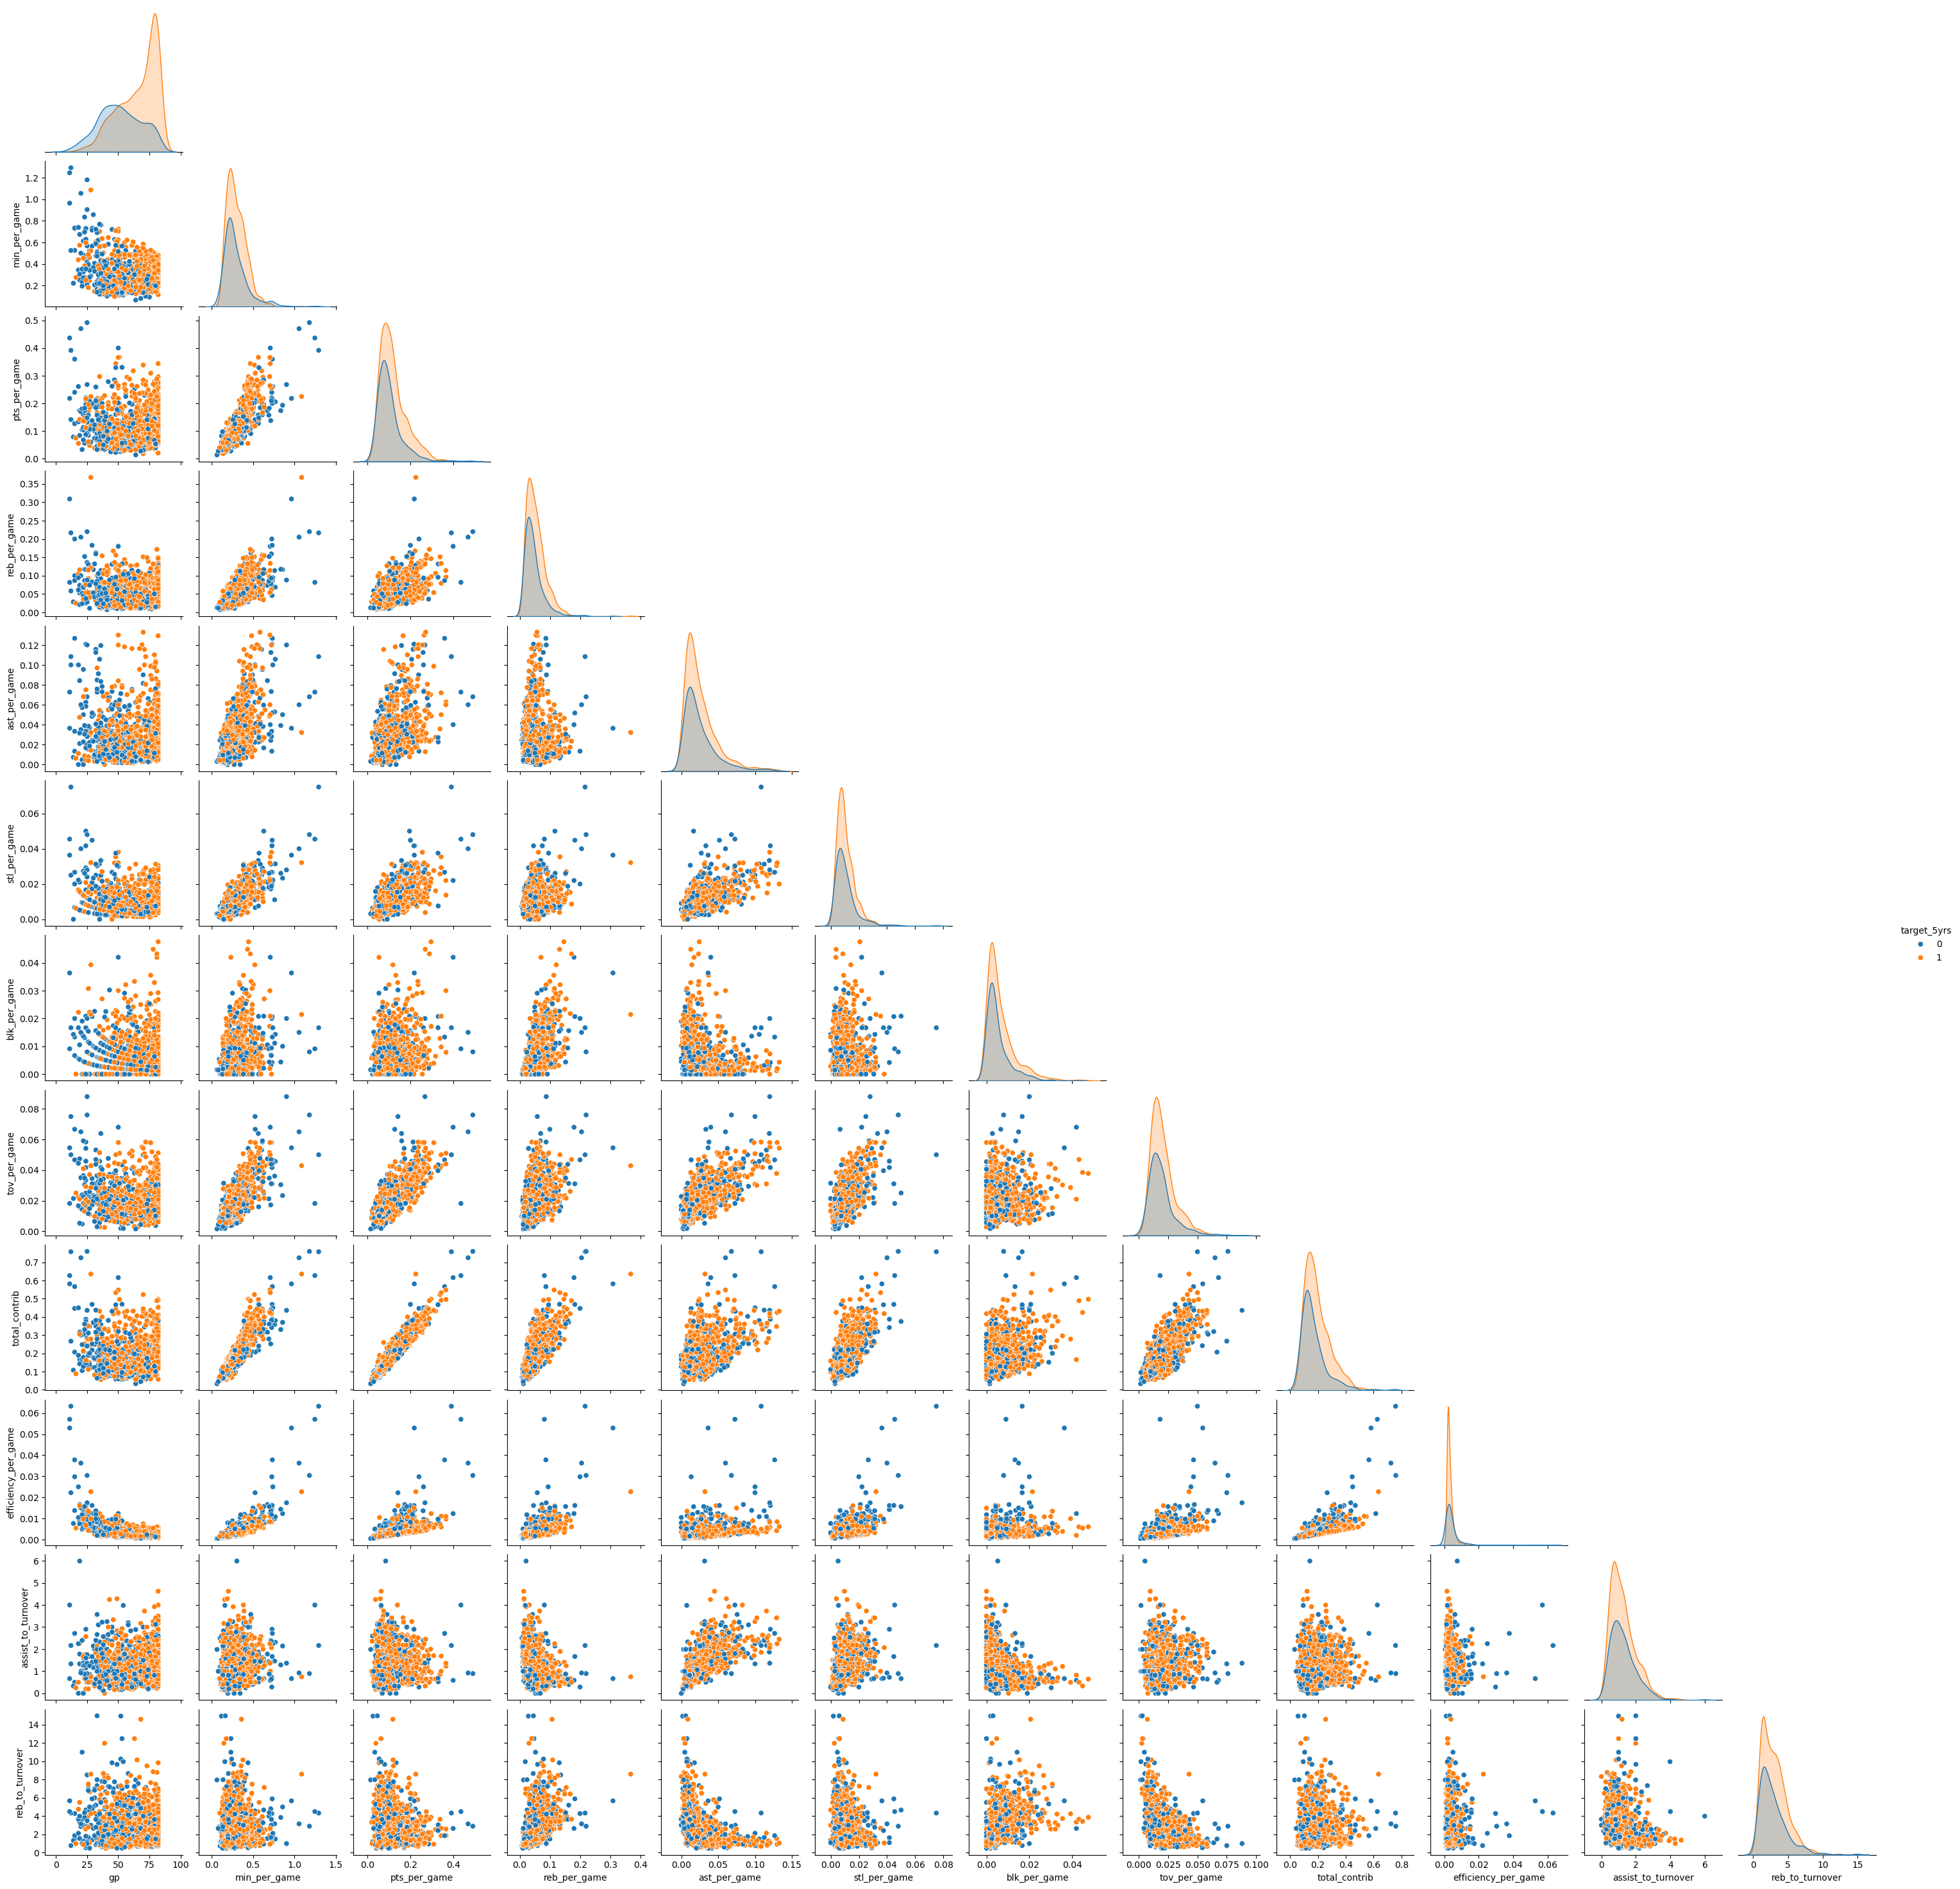

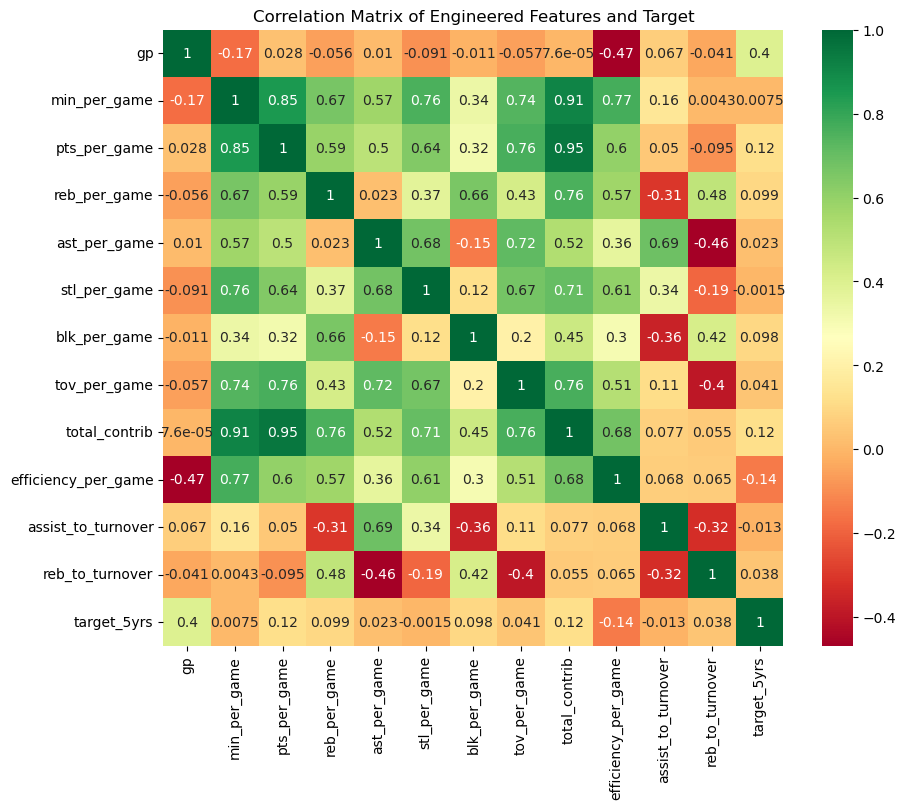

In [189]:
# ================================
# Feature Engineering for NBA Career Longevity
# ================================

# Create per-game averages (normalize by games played)
df['pts_per_game'] = df['pts'] / df['gp']
df['reb_per_game'] = df['reb'] / df['gp']
df['ast_per_game'] = df['ast'] / df['gp']
df['stl_per_game'] = df['stl'] / df['gp']
df['blk_per_game'] = df['blk'] / df['gp']
df['tov_per_game'] = df['tov'] / df['gp']
df['min_per_game'] = df['min'] / df['gp']

# Total contribution per game (positive stats minus turnovers)
df['total_contrib'] = df['pts_per_game'] + df['reb_per_game'] + df['ast_per_game'] + df['stl_per_game'] + df['blk_per_game'] - df['tov_per_game']

# Efficiency metric
df['efficiency_per_game'] = df['total_contrib'] / df['gp']

# Ratios to capture skill balance
df['assist_to_turnover'] = df['ast_per_game'] / (df['tov_per_game'] + 1e-5)  # avoid division by zero
df['reb_to_turnover'] = df['reb_per_game'] / (df['tov_per_game'] + 1e-5)

# Drop original totals (optional, since we now use per-game and derived metrics)
df = df.drop(columns=['pts', 'reb', 'ast', 'stl', 'blk', 'tov', 'min'])

# Updated numeric features for EDA / modeling
numeric_features = [
    'gp', 'min_per_game', 'pts_per_game', 'reb_per_game', 
    'ast_per_game', 'stl_per_game', 'blk_per_game', 
    'tov_per_game', 'total_contrib', 'efficiency_per_game',
    'assist_to_turnover', 'reb_to_turnover'
]

# ================================
# Exploratory Data Analysis (EDA)
# ================================

# Histogram of numeric features
df[numeric_features].hist(bins=20, figsize=(12,8))
plt.suptitle('Distribution of Engineered Numeric Features')
plt.show()

# Pairplot to visualize relationship with target_5yrs
sns.pairplot(df[numeric_features + ['target_5yrs']], hue='target_5yrs', diag_kind='kde', corner=True)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_features + ['target_5yrs']].corr(), annot=True, cmap='RdYlGn')
plt.title('Correlation Matrix of Engineered Features and Target')
plt.show()


### Explanation

#### Feature Engineering
Per-game averages (e.g. pts_per_game, reb_per_game etc.) normalize raw totals by games played (gp). This ensures that players who plaued fewer games aren't unfairly penalized and allows fair comparisons between all players.
Total contribution (total_contrib) sums key stats while subtracting turnovers, giving a single metric of overall player impact.

Efficiency per game (efficiency_per_game) further normalizes contributions, helping the model detect players who are productive relative to playing time.

Skill balance ratios (assist_to_turnover, reb_to_turnover) capture qualitative aspects of a player’s game, like ball-handling efficiency and rebounding impact versus mistakes.

Dropping raw totals reduces redundancy and multicollinearity. The model now focuses on normalized, informative features.

#### Exploratory Data Analysis (EDA)
Histograms show the distribution of numeric features, highlight skewed features, and identify extreme values or outliers.

Pairplots visualize relationships between features and the target (target_5yrs). Diagonal plots show feature distributions; off-diagonal plots show potential correlations and separability for the target classes.

Correlation heatmap helps identify highly correlated features that may provide similar information. It also indicates which features are more strongly associated with target_5yrs, guiding feature selection.


## Model Comparison

In [191]:
# ================================
# Best Model Comparison: Before vs After Feature Engineering
# ================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Split train/test for engineered dataset
X = df.drop(columns=['target_5yrs'])
y = df['target_5yrs']

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X, y, test_size=0.2, random_state=2026
)

# Train Gradient Boosting on engineered features
gbt_eng = GradientBoostingClassifier(random_state=2026)
gbt_eng.fit(X_train_eng, y_train_eng)
y_pred_eng = gbt_eng.predict(X_test_eng)

# Metrics after feature engineering
after_feature_eng_results = {
    'Accuracy': accuracy_score(y_test_eng, y_pred_eng),
    'Precision': precision_score(y_test_eng, y_pred_eng),
    'Recall': recall_score(y_test_eng, y_pred_eng),
    'F1 Score': f1_score(y_test_eng, y_pred_eng)
}

# Print comparison
print("Before Feature Engineering:", base_results['Gradient Boosting'])
print("After Feature Engineering:", after_feature_eng_results)


Before Feature Engineering: {'Accuracy': 0.6380597014925373, 'Precision': 0.65, 'Recall': 0.7748344370860927, 'F1 Score': 0.7069486404833837}
After Feature Engineering: {'Accuracy': 0.6828358208955224, 'Precision': 0.6987951807228916, 'Recall': 0.7682119205298014, 'F1 Score': 0.7318611987381703}


### Explaination
This code compares the best model's performance before and after feature engineering.

As explained earlier about Gradient Boosting being the best base model, the model is trained on the engineered dataset, which may include selected features, transformed variables or aggregated statistics

Evaluation: Performance metrics Accuracy, Precision, Recall, and F1 Score are calculated on the test set to evaluate how feature engineering impacted model predictions.

Comparison: Printing results before and after feature engineering allows me to assess whether feature engineering improved the model, helping justify the final choice of features for deployment.


In [193]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Parameter distribution for Gradient Boosting
param_dist_gbt = {
    'n_estimators': randint(50, 150),        # Number of boosting stages
    'learning_rate': uniform(0.01, 0.3),     # Step size shrinkage
    'max_depth': randint(3, 8),              # Maximum depth of each tree
    'min_samples_split': randint(2, 5),      # Minimum samples to split a node
    'subsample': uniform(0.6, 0.4),          # Fraction of samples used for fitting each base learner
    'max_features': ['sqrt', 'log2']         # Number of features to consider at each split
}

# RandomizedSearchCV for Gradient Boosting
rs_gbt = RandomizedSearchCV(
    estimator=gbt_eng,
    param_distributions=param_dist_gbt,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=2026
)
rs_gbt.fit(X_train_eng, y_train_eng)

# Best estimator after tuning
best_gbt = rs_gbt.best_estimator_
y_pred_best = best_gbt.predict(X_test_eng)

# Metrics after tuning
after_tuning_results = {
    'Accuracy': accuracy_score(y_test_eng, y_pred_best),
    'Precision': precision_score(y_test_eng, y_pred_best),
    'Recall': recall_score(y_test_eng, y_pred_best),
    'F1 Score': f1_score(y_test_eng, y_pred_best)
}

# Print comparison
print("After Feature Engineering, Before Tuning:", after_feature_eng_results)
print("After Feature Engineering and Hyperparameter Tuning:", after_tuning_results)
print("Best Parameters:", rs_gbt.best_params_)


After Feature Engineering, Before Tuning: {'Accuracy': 0.6828358208955224, 'Precision': 0.6987951807228916, 'Recall': 0.7682119205298014, 'F1 Score': 0.7318611987381703}
After Feature Engineering and Hyperparameter Tuning: {'Accuracy': 0.6902985074626866, 'Precision': 0.7023809523809523, 'Recall': 0.7814569536423841, 'F1 Score': 0.7398119122257053}
Best Parameters: {'learning_rate': np.float64(0.16181103304104258), 'max_depth': 3, 'max_features': 'log2', 'min_samples_split': 3, 'n_estimators': 108, 'subsample': np.float64(0.8381111638977223)}


### Explanation

This code performs hyperparameter tuning for the Gradient Boosting model to optimize its performance after feature engineering.

Comparison: Printing results before and after hyperparameter tuning allows me to demonstrate improvement in model performance and justify the chouce of final model for deployment.